# RQ 7.2

## Setup

In [1]:
import io, json, random
from collections import defaultdict
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from shared_class_labels import build_index, report, CLASS_NAMES, N_CLASSES, CLASS_INDEX

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("PyTorch", torch.__version__)
print("Device :", DEVICE)


ModuleNotFoundError: No module named 'shared_class_labels'

## Settings

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 3 
MAX_IMAGES_PER_CLASS = 200   
TEST_FRACTION = 0.2   
SEED = 42

# Must be 0 in a notebook on macOS
NUM_WORKERS = 0

print(f"{MAX_IMAGES_PER_CLASS} images/class, {EPOCHS} epochs")

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2 ** 32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seed()
print(f"seed = {SEED}")


200 images/class, 3 epochs
seed = 42


## Shared class labels
The two datasets have different naming conventions for the same classes. This list is used to link the two datasets to each other based on the class names. 

In [ ]:
SHARED_CLASSES: dict[str, tuple[str, str]] = {
    "apple_scab": ("Apple___Apple_scab", "Apple Scab Leaf"),
    "apple_rust": ("Apple___Cedar_apple_rust", "Apple rust leaf"),
    "apple_healthy": ("Apple___healthy", "Apple leaf"),
    "blueberry_healthy": ("Blueberry___healthy", "Blueberry leaf"),
    "cherry_healthy": ("Cherry_(including_sour)___healthy", "Cherry leaf"),
    "corn_gray_spot": ("Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot", "Corn Gray leaf spot"),
    "corn_rust": ("Corn_(maize)___Common_rust_", "Corn rust leaf"),
    "corn_blight": ("Corn_(maize)___Northern_Leaf_Blight", "Corn leaf blight"),
    "grape_black_rot": ("Grape___Black_rot", "grape leaf black rot"),
    "grape_healthy": ("Grape___healthy", "grape leaf"),
    "peach_healthy": ("Peach___healthy", "Peach leaf"),
    "pepper_healthy": ("Pepper,_bell___healthy", "Bell_pepper leaf"),
    "potato_early_blight": ("Potato___Early_blight", "Potato leaf early blight"),
    "potato_late_blight": ("Potato___Late_blight", "Potato leaf late blight"),
    "raspberry_healthy": ("Raspberry___healthy", "Raspberry leaf"),
    "soybean_healthy": ("Soybean___healthy", "Soyabean leaf"),
    "squash_mildew": ("Squash___Powdery_mildew", "Squash Powdery mildew leaf"),
    "strawberry_healthy": ("Strawberry___healthy", "Strawberry leaf"),
    "tomato_bacterial_spot": ("Tomato___Bacterial_spot", "Tomato leaf bacterial spot"),
    "tomato_early_blight": ("Tomato___Early_blight", "Tomato Early blight leaf"),
    "tomato_late_blight": ("Tomato___Late_blight", "Tomato leaf late blight"),
    "tomato_leaf_mold": ("Tomato___Leaf_Mold", "Tomato mold leaf"),
    "tomato_septoria": ("Tomato___Septoria_leaf_spot", "Tomato Septoria leaf spot"),
    "tomato_yellow_virus": ("Tomato___Tomato_Yellow_Leaf_Curl_Virus", "Tomato leaf yellow virus"),
    "tomato_mosaic_virus": ("Tomato___Tomato_mosaic_virus", "Tomato leaf mosaic virus"),
    "tomato_healthy": ("Tomato___healthy", "Tomato leaf"),
}

CLASS_NAMES = list(SHARED_CLASSES)
N_CLASSES = len(CLASS_NAMES)
print(f"{N_CLASSES} number of classes shared between PlantVillage (lab-condition) and PlantDoc (field-condition)")

26 number of classes shared between PlantVillage (lab-condition) and PlantDoc (field-condition)


## Paths

In [ ]:
from pathlib import Path
import sys

PROJECT = Path.cwd().parent

assert (PROJECT / "data" / "raw").is_dir(), \
f"expected data/raw under {PROJECT}\ncwd is {Path.cwd()}"

sys.path.append(str(PROJECT / "rq72" / "scripts"))
from shared_class_labels import build_index, report, CLASS_NAMES, N_CLASSES

index = build_index()
report(index)

lab_pairs = index["lab"]       
field_pairs = index["field"]

lab   root    /Users/shreyabharat/Projects/COS801-GroupProject/data/raw/plantvillage/plantvillage dataset/color
field root    /Users/shreyabharat/Projects/COS801-GroupProject/data/raw/plantdoc/train
              /Users/shreyabharat/Projects/COS801-GroupProject/data/raw/plantdoc/test

class                      lab   field
--------------------------------------
apple_scab                 630      93
apple_rust                 275      88
apple_healthy             1645      91
blueberry_healthy         1502     115
cherry_healthy             854      57
corn_gray_spot             513      68
corn_rust                 1192     116
corn_blight                985     191
grape_black_rot           1180      64
grape_healthy              423      69
peach_healthy              360     111
pepper_healthy            1478      61
potato_early_blight       1000     116
potato_late_blight        1000     105
raspberry_healthy          371     119
soybean_healthy           5090      65
squash_milde

## Exploratory Data Analysis

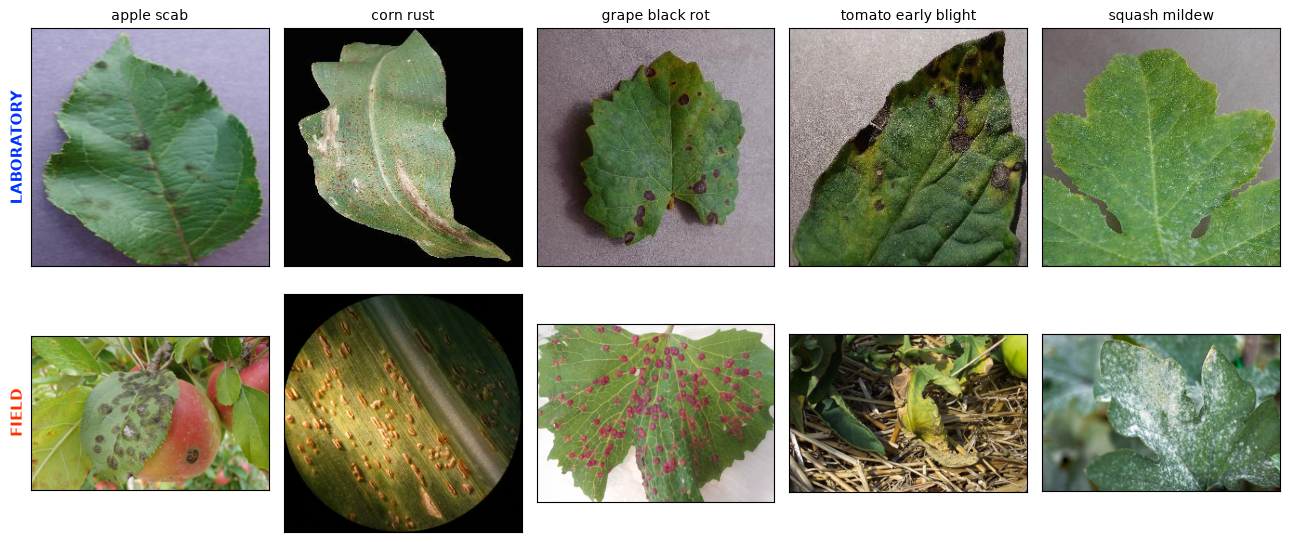

In [ ]:
def first_image_per_class(pairs):
    first = {}
    for path, label in pairs:
        first.setdefault(label, path)
    return first

lab_example = first_image_per_class(lab_pairs)
field_example = first_image_per_class(field_pairs)

show_classes = ["apple_scab", "corn_rust", "grape_black_rot",
                "tomato_early_blight", "squash_mildew"]

rows = [("LABORATORY", lab_example, "#0033ff"),
        ("FIELD",      field_example, "#ff3300")]

fig, axes = plt.subplots(2, len(show_classes),
                         figsize=(2.6 * len(show_classes), 5.8))

for col, name in enumerate(show_classes):
    label = CLASS_INDEX[name]
    for row, (domain, examples, colour) in enumerate(rows):
        ax = axes[row, col]
        ax.set_xticks([]); ax.set_yticks([])
        path = examples.get(label)
        if path is None:
            ax.text(0.5, 0.5, "no image", ha="center", va="center",
                    transform=ax.transAxes, fontsize=9, color="grey")
        else:
            img = Image.open(path).convert("RGB")
            # img = img.resize((224, 224))   # uncomment for an even grid
            ax.imshow(img)
        if col == 0:
            ax.set_ylabel(domain, fontsize=11, fontweight="bold", color=colour)
        if row == 0:
            ax.set_title(name.replace("_", " "), fontsize=10)

fig.tight_layout()
plt.show()